In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from PIL import Image
from sklearn.metrics import classification_report

In [4]:
from google.colab import drive
drive.mount('/content/drive')

# List the contents of the specified directory
data_path = '/content/drive/MyDrive/AI ML/Data/FruitinAmazon'

# Check if the directory exists before listing its contents
import os
if os.path.exists(data_path):
    print(f"Contents of {data_path}:")
    for item in os.listdir(data_path):
        print(item)
else:
    print(f"Error: The path '{data_path}' does not exist or is not accessible. Please ensure the path is correct and Google Drive is mounted properly.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Contents of /content/drive/MyDrive/AI ML/Data/FruitinAmazon:
train
test
fruit_model_augmented.keras
fruit_model.keras
fruit_model_Finetune.keras


Total classes found: 6
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


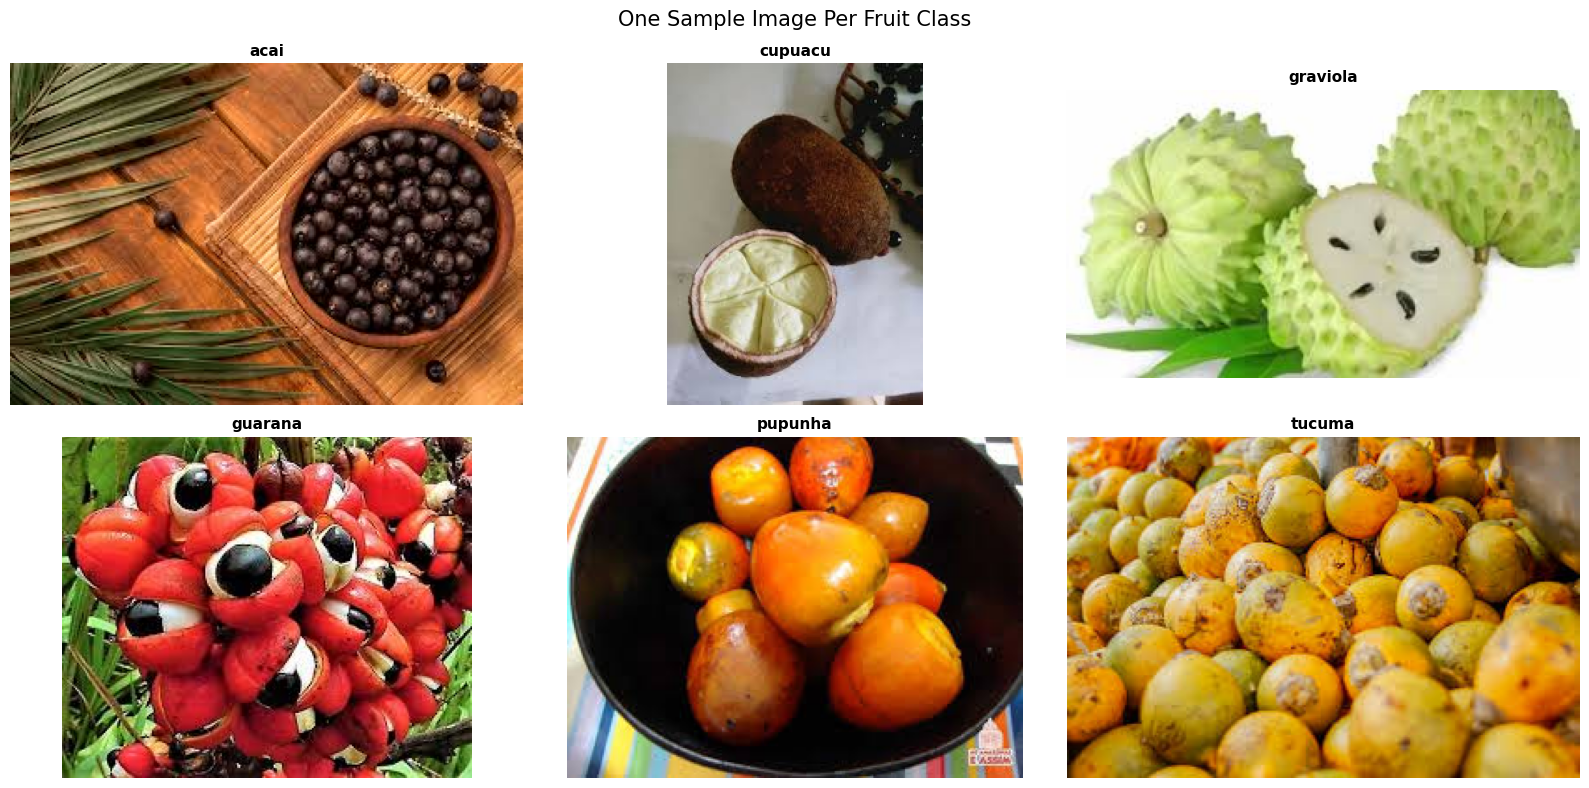

In [5]:
train_dir = '/content/drive/MyDrive/AI ML/Data/FruitinAmazon/train'

class_dirs = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

print(f"Total classes found: {len(class_dirs)}")
print("Class names:", class_dirs)


num_classes = len(class_dirs)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(16, 8))
axes = axes.flatten()

for i, class_name in enumerate(class_dirs):
    class_path = os.path.join(train_dir, class_name)
    all_images = os.listdir(class_path)

    random_img_name = random.choice(all_images)
    img_path = os.path.join(class_path, random_img_name)

    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(class_name, fontsize=11, fontweight='bold')
    axes[i].axis('off')


for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("One Sample Image Per Fruit Class", fontsize=15)
plt.tight_layout()
plt.show()

In [6]:
IMG_HEIGHT  = 128
IMG_WIDTH   = 128
BATCH_SIZE  = 32
VAL_SPLIT   = 0.2

#Training Dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels        = 'inferred',
    label_mode    = 'int',
    image_size    = (IMG_HEIGHT, IMG_WIDTH),
    interpolation = 'nearest',
    batch_size    = BATCH_SIZE,
    shuffle       = True,
    validation_split = VAL_SPLIT,
    subset        = 'training',
    seed          = 123            # fixed seed
)

#Validation Dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels        = 'inferred',
    label_mode    = 'int',
    image_size    = (IMG_HEIGHT, IMG_WIDTH),
    interpolation = 'nearest',
    batch_size    = BATCH_SIZE,
    shuffle       = False,
    validation_split = VAL_SPLIT,
    subset        = 'validation',
    seed          = 123
)

# Get class names from the dataset
class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)
print("Number of classes:", num_classes)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [7]:
# Normalization
rescale = tf.keras.layers.Rescaling(1./255)

# .map() applies the rescaling function to every batch
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds   = val_ds.map(lambda x, y: (rescale(x), y))


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Datasets ready!")

Datasets ready!


In [9]:
from tensorflow.keras import layers, models
from tensorflow.keras.layers import BatchNormalization

data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]

def data_augmentation(images):
  for layer in data_augmentation_layers:
    images = layer(images)
  return images

model = models.Sequential([
  # Data augmentation applied using Lambda layer
  layers.Lambda(data_augmentation, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
  layers.Rescaling(1./255),

#conv Block 1
 layers.Conv2D(32,(3,3), padding='same', activation='relu', input_shape=(IMG_HEIGHT,IMG_WIDTH, 3)),
BatchNormalization(),
 #max Pooling
 #reduces spatial size by half increasing computation speed and more focus on dominant feautures
 layers.MaxPooling2D((2,2), strides = 2),


 #conv Block 2
 layers.Conv2D(32,(3,3), padding='same', activation='relu'),
 layers.MaxPooling2D((2,2), strides = 2),


 #Flattens -> Converts 3D Feature map to 1D vector
 layers.Flatten(),


 #Hidden layer 1
 layers.Dense(128, activation = 'relu'),
 BatchNormalization(),
 #hidden layer 2

 layers.Dense(62, activation= 'relu'),
 layers.Dense(num_classes, activation='softmax')
])


# Print the architecture table
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 62)             │         7,998 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           378 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,592 (16.07 MB)

 Trainable params: 4,213,272 (16.07 MB)

 Non-trainable params: 320 (1.25 KB)

In [10]:
from tensorflow.keras.optimizers import Adam
opt = Adam(learning_rate=0.0001)
model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("Model Compiled")


Model Compiled


In [12]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    filepath        = '/content/drive/MyDrive/AI ML/Data/FruitinAmazon/fruit_model_Finetune.keras',
    monitor         = 'val_accuracy',
    save_best_only  = True,
    verbose         = 1
)

# Callback 2: Early Stopping
early_stop = EarlyStopping(
    monitor              = 'val_accuracy',
    patience             = 10,
    restore_best_weights = True,
    verbose              = 1
)

# Train
history = model.fit(
    train_ds,
    epochs          = 100,          # max epochs
    validation_data = val_ds,
    callbacks       = [checkpoint, early_stop],
)

print("\n Training complete!")

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2726 - loss: 1.7574
Epoch 1: val_accuracy improved from None to 0.83333, saving model to /content/drive/MyDrive/AI ML/Data/FruitinAmazon/fruit_model_Finetune.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI ML/Data/FruitinAmazon/fruit_model_Finetune.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 28s 7s/step - accuracy: 0.3333 - loss: 1.7263 - val_accuracy: 0.8333 - val_loss: 1.7892
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 901ms/step - accuracy: 0.4832 - loss: 1.4922
Epoch 2: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 984ms/step - accuracy: 0.5278 - loss: 1.4504 - val_accuracy: 0.8333 - val_loss: 1.7875
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.4832 - loss: 1.3065
Epoch 3: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 662ms/step - accuracy: 0.5278 - loss: 1.2662 - val_accuracy: 0.2222 - val_loss: 1.7892
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/ste

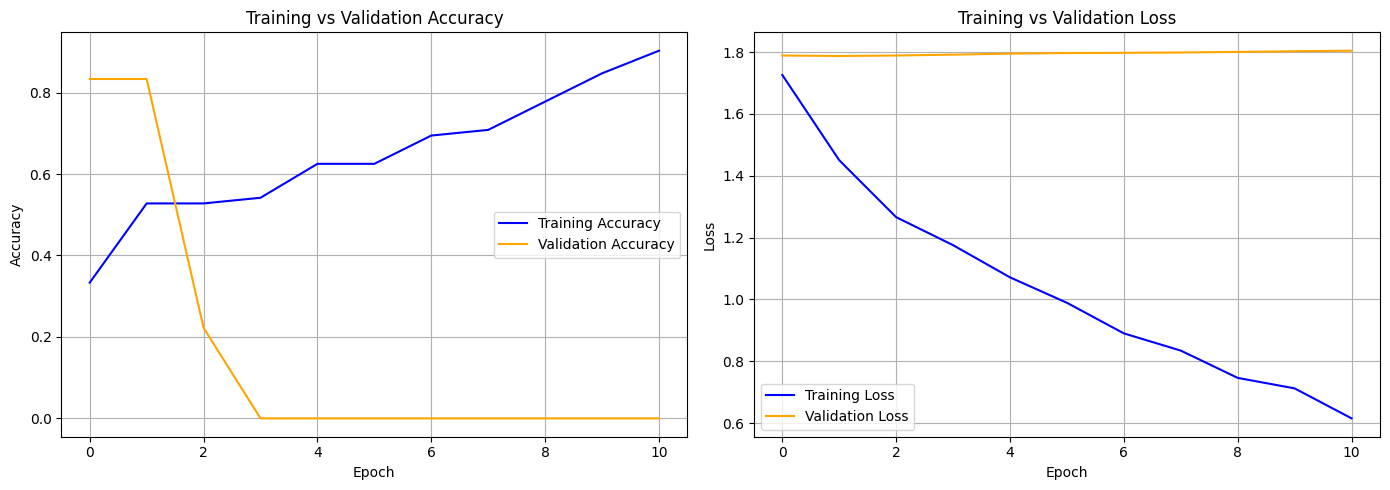

In [13]:
# history.history stores all the metrics recorded during training

acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(epochs_range, acc,     label='Training Accuracy',   color='blue')
ax1.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
ax1.set_title('Training vs Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(epochs_range, loss,     label='Training Loss',   color='blue')
ax2.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
ax2.set_title('Training vs Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

In [14]:
# Load test dataset (separate from train)
test_dir = '/content/drive/MyDrive/AI ML/Data/FruitinAmazon/test'

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels       = 'inferred',
    label_mode   = 'int',
    image_size   = (IMG_HEIGHT, IMG_WIDTH),
    batch_size   = BATCH_SIZE,
    shuffle      = False
)

# Normalize
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Evaluate
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\n Test Loss:     {test_loss:.4f}")
print(f" Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 0.1667 - loss: 1.7913

 Test Loss:     1.7913
 Test Accuracy: 0.1667  (16.67%)


# Image Classification via fine-tuning with VGG16

In [17]:
from tensorflow import keras

image_size = (224, 224)
batch_size = 32
train_ds, val_ds = keras.utils.image_dataset_from_directory(
  train_dir,
  validation_split=0.2,
  subset="both",
  seed=1337,
  image_size=image_size,
  batch_size=batch_size,
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


In [18]:
from tensorflow.keras.applications import VGG16
# Load the VGG16 model pre-trained on ImageNet, without the top classification layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

#Freeze the base model
for layer in base_model.layers:
  layer.trainable = False

In [19]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
x = base_model.output
x = GlobalAveragePooling2D()(x) # Reduces dimensions (height, width) to a single vector per image
x = Dense(1024, activation='relu')(x) # Fully connected layer with 1024 neurons


In [20]:
from tensorflow.keras.models import Model
# Create the final model
model = Model(inputs=base_model.input, outputs=x)

In [21]:
from tensorflow.keras.optimizers import Adam

# Get the number of classes from class_names
num_classes_vgg = len(class_names)

# Add the final output layer with the correct number of classes
predictions = Dense(num_classes_vgg, activation='softmax')(x)

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# One-hot encode the labels for categorical_crossentropy
# Get the number of classes from the dataset (assuming labels are 0-indexed)
num_classes = len(class_names)

def one_hot_encode(image, label):
    return image, tf.one_hot(label, num_classes)

train_ds_one_hot = train_ds.map(one_hot_encode)
val_ds_one_hot = val_ds.map(one_hot_encode)


# Train the model
epochs = 10 # You can adjust the number of epochs
model.fit(
    train_ds_one_hot,
    epochs=epochs,
    validation_data=val_ds_one_hot,
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 61s 17s/step - accuracy: 0.2500 - loss: 6.5134 - val_accuracy: 0.1667 - val_loss: 12.8475
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 60s 21s/step - accuracy: 0.6250 - loss: 6.4606 - val_accuracy: 0.4444 - val_loss: 7.4767
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 71s 15s/step - accuracy: 0.8750 - loss: 1.1992 - val_accuracy: 0.4444 - val_loss: 5.4565
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 50s 16s/step - accuracy: 0.8472 - loss: 0.6864 - val_accuracy: 0.4444 - val_loss: 8.4130
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 50s 16s/step - accuracy: 0.8889 - loss: 0.8723 - val_accuracy: 0.5000 - val_loss: 6.5648
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 50s 16s/step - accuracy: 0.9722 - loss: 0.0697 - val_accuracy: 0.7222 - val_loss: 4.1694
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 90s 20s/step - accuracy: 1.0000 - loss: 4.2724e-04 - val_accuracy: 0.6111 - val_loss: 3.9549
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 76s 17s/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.6111 - val_loss: 4.

In [22]:
loss, accuracy = model.evaluate(val_ds_one_hot)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 0.4444 - loss: 4.5346
Validation Loss: 4.5346
Validation Accuracy: 0.4444


In [23]:
from sklearn.metrics import classification_report

# Get true labels and predicted labels for the validation set
y_true = np.concatenate([y.numpy() for x, y in val_ds_one_hot], axis=0)
y_pred_probabilities = model.predict(val_ds_one_hot)
y_pred = np.argmax(y_pred_probabilities, axis=1)

# Assuming y_true is one-hot encoded, convert it to class indices
y_true_indices = np.argmax(y_true, axis=1)

print("\nClassification Report:")
print(classification_report(y_true_indices, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step

Classification Report:
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         3
     cupuacu       1.00      0.75      0.86         4
    graviola       1.00      1.00      1.00         1
     guarana       0.25      1.00      0.40         1
     pupunha       0.50      0.25      0.33         4
      tucuma       0.29      0.40      0.33         5

    accuracy                           0.44        18
   macro avg       0.51      0.57      0.49        18
weighted avg       0.48      0.44      0.43        18

